## TAF15 knockdown

In [ ]:
library(sleuth)

# ---------------------------------------------------------------------
# Differential expression with sleuth (kallisto outputs)
# ---------------------------------------------------------------------
# Purpose:
#   Fit a model ~ condition and test knockdown vs control using a Wald test.
#
# Input:
#   - kallisto quantification directories (one per sample) listed in sample_to_condition$path
#
# Output:
#   - TAF15_HepG2_results_table.csv (sleuth results table)

# Sample metadata (update paths to your environment)
sample_to_condition <- data.frame(
  sample = c("kd_rep1", "kd_rep2", "control_rep1", "control_rep2"),
  path = c(
    "../../results/reproducibility/gwas_resources/kd_TAF15_HepG2/output_rep1",
    "../../results/reproducibility/gwas_resources/kd_TAF15_HepG2/output_rep2",
    "../../results/reproducibility/gwas_resources/control_TAF15_HepG2/output_rep1",
    "../../results/reproducibility/gwas_resources/control_TAF15_HepG2/output_rep2"
  ),
  condition = rep(c("knockdown", "control"), each = 2)
)

# Initialize sleuth object
so <- sleuth_prep(sample_to_condition, ~ condition)

# Fit full model
so <- sleuth_fit(so)

# Wald test (knockdown vs control)
so <- sleuth_wt(so, "conditionknockdown")

# Extract results table
results_table <- sleuth_results(so, "conditionknockdown", "wt", show_all = FALSE)
write.csv(results_table, "TAF15_HepG2_results_table.csv", row.names = FALSE)
print("done")


reading in kallisto results

dropping unused factor levels

.
.
.
.


normalizing est_counts

84809 targets passed the filter

normalizing tpm

merging in metadata

summarizing bootstraps



fitting measurement error models

shrinkage estimation

5 NA values were found during variance shrinkage estimation due to mean observation values outside of the range used for the LOESS fit.
The LOESS fit will be repeated using exact computation of the fitted surface to extrapolate the missing values.
These are the target ids with NA values: ENST00000414548.1|ENSG00000230310.1|OTTHUMG00000156402.1|OTTHUMT00000344080.1|LINC02926-201|LINC02926|543|lncRNA|, ENST00000462183.1|ENSG00000023909.10|OTTHUMG00000010562.2|OTTHUMT00000029171.1|GCLM-202|GCLM|583|protein_coding_CDS_not_defined|, ENST00000637295.1|ENSG00000283519.1|-|-|U2.20-201|U2|81|snRNA|, ENST00000649154.1|ENSG00000291200.1|-|OTTHUMT00000501520.1|RHOXF1P1-203|RHOXF1P1|1544|lncRNA|, ENST00000693292.1|ENSG00000289426.1|-|-|ENST00000693292|ENSG

Loading required package: ggplot2

Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”
Warning message:
“The `size` argument of `element_rect()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


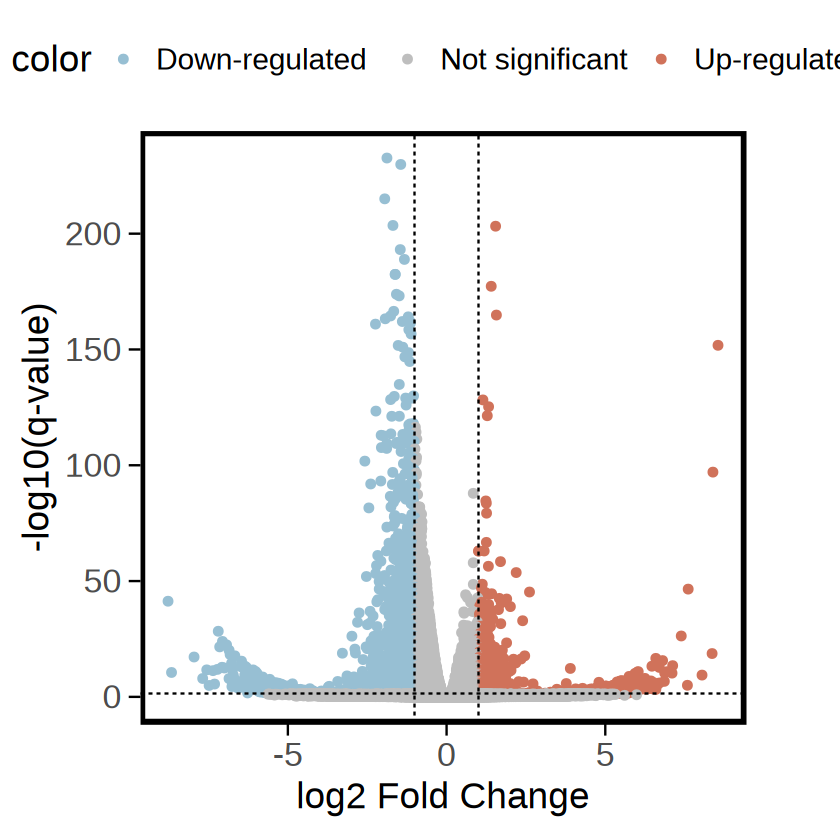

In [ ]:
library(gghalves)
library(ggsignif)
library(ggplot2)

# ---------------------------------------------------------------------
# Volcano plot from sleuth results
# ---------------------------------------------------------------------
# Input:
#   - TAF15_HepG2_results_table.csv (generated in previous cell)
#
# Output:
#   - volcano_plot_TAF15_HepG2.png

# Load results table
results_table <- read.csv("TAF15_HepG2_results_table.csv")

# Create a color label column
results_table$color <- ifelse(
    results_table$qval < 0.05 & results_table$b > 1, "Up-regulated",
    ifelse(results_table$qval < 0.05 & results_table$b < -1, "Down-regulated", "Not significant")
)

# Filter ENST transcripts
filtered_results <- results_table[grepl("ENST", results_table$target_id), ]
filtered_results$short_id <- sub("\\..*", "", filtered_results$target_id)

# Remove the top five smallest qval transcripts to reduce extreme points
top5_ids <- filtered_results[order(filtered_results$qval), ][1:5, "target_id"]
results_table_ <- results_table[!results_table$target_id %in% top5_ids, ]

# Volcano plot
volcano_plot <- ggplot(results_table_, aes(x = b, y = -log10(qval))) +
    geom_point(aes(color = color), size = 2) +
    scale_color_manual(values = c(
        "Up-regulated" = "#d0725a", 
        "Down-regulated" = "#97bfd3", 
        "Not significant" = "gray"
    )) +
    geom_hline(yintercept = -log10(0.05), linetype = "dashed", color = "black") +
    geom_vline(xintercept = c(-1, 1), linetype = "dashed", color = "black") +
    theme_minimal(base_size = 22) +
    xlab("log2 Fold Change") + 
    ylab("-log10(q-value)") +
    theme(
        legend.position = "top",
        panel.border = element_rect(colour = "black", fill = NA, size = 2),
        panel.grid = element_blank(),
        axis.ticks = element_line(size = 0.5),
        axis.ticks.length = unit(0.25, "cm"),
        plot.margin = unit(c(0.5, 2, 0.5, 0.5), "cm"),
        axis.text = element_text(size = 20)
    )

# Save PNG
ggsave(
  "volcano_plot_TAF15_HepG2.png",
  plot = volcano_plot,
  width = 8,
  height = 8,
  dpi = 300
)

# Display plot
volcano_plot

In [ ]:
library(sleuth)

# ---------------------------------------------------------------------
# Differential expression with sleuth (kallisto outputs)
# ---------------------------------------------------------------------
# Purpose:
#   Fit a model ~ condition and test knockdown vs control using a Wald test.
#
# Input:
#   - kallisto quantification directories (one per sample) listed in sample_to_condition$path
#
# Output:
#   - TAF15_K562_results_table.csv (sleuth results table)

# Sample metadata (update paths to your environment)
sample_to_condition <- data.frame(
  sample = c("kd_rep1", "kd_rep2", "control_rep1", "control_rep2"),
  path = c(
    "../../results/reproducibility/gwas_resources/kd_TAF15_K562/output_rep1",
    "../../results/reproducibility/gwas_resources/kd_TAF15_K562/output_rep2",
    "../../results/reproducibility/gwas_resources/control_TAF15_K562/output_rep1",
    "../../results/reproducibility/gwas_resources/control_TAF15_K562/output_rep2"
  ),
  condition = rep(c("knockdown", "control"), each = 2)
)

# Initialize sleuth object
so <- sleuth_prep(sample_to_condition, ~ condition)

# Fit full model
so <- sleuth_fit(so)

# Wald test (knockdown vs control)
so <- sleuth_wt(so, "conditionknockdown")

# Extract results table
results_table <- sleuth_results(so, "conditionknockdown", "wt", show_all = FALSE)
write.csv(results_table, "TAF15_K562_results_table.csv", row.names = FALSE)
print("done")


reading in kallisto results

dropping unused factor levels

.
.
.
.


normalizing est_counts

83978 targets passed the filter

normalizing tpm

merging in metadata

summarizing bootstraps



fitting measurement error models

shrinkage estimation

22 NA values were found during variance shrinkage estimation due to mean observation values outside of the range used for the LOESS fit.
The LOESS fit will be repeated using exact computation of the fitted surface to extrapolate the missing values.
These are the target ids with NA values: ENST00000374222.6|ENSG00000158062.21|OTTHUMG00000003382.13|-|UBXN11-206|UBXN11|1660|protein_coding|, ENST00000378731.6|ENSG00000205089.8|OTTHUMG00000059737.1|OTTHUMT00000132833.1|CCNI2-201|CCNI2|2613|protein_coding|, ENST00000451637.1|ENSG00000155545.20|OTTHUMG00000059589.12|OTTHUMT00000132527.2|MIER3-207|MIER3|304|nonsense_mediated_decay|, ENST00000455798.6|ENSG00000170892.13|OTTHUMG00000066515.32|OTTHUMT00000157368.4|TSEN34-205|TSEN34|2332|protein_coding|, 

Loading required package: ggplot2

Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”
Warning message:
“The `size` argument of `element_rect()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


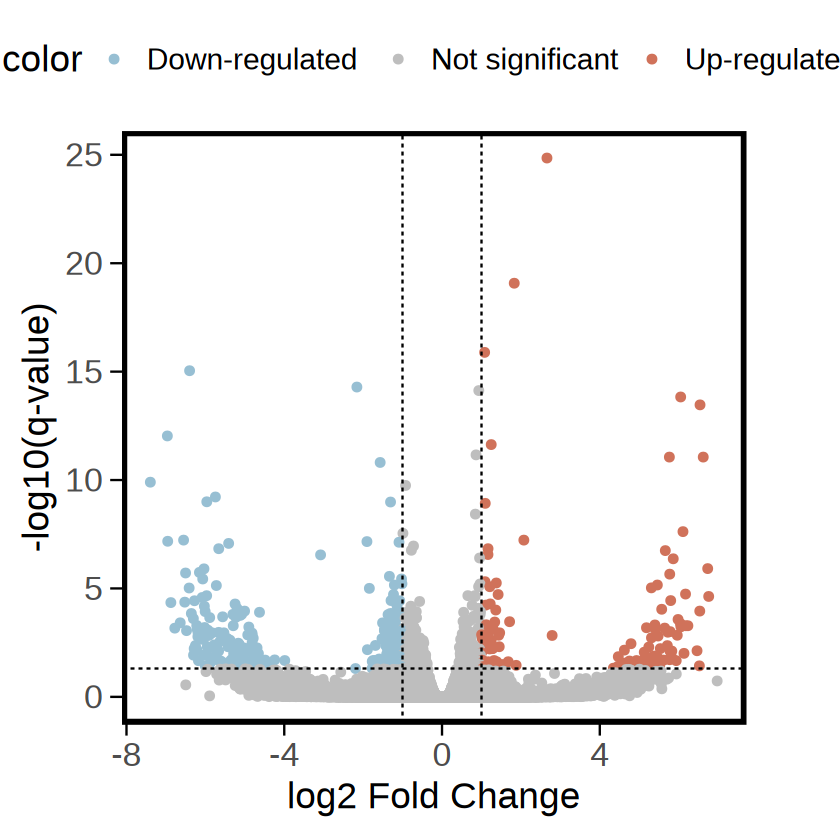

In [2]:
library(gghalves)
library(ggsignif)
library(ggplot2)

# ---------------------------------------------------------------------
# Volcano plot from sleuth results
# ---------------------------------------------------------------------
# Input:
#   - TAF15_K562_results_table.csv (generated in previous cell)
#
# Output:
#   - volcano_plot_TAF15_K562.png

# Load results table
results_table <- read.csv("TAF15_K562_results_table.csv")

# Create a color label column
results_table$color <- ifelse(
    results_table$qval < 0.05 & results_table$b > 1, "Up-regulated",
    ifelse(results_table$qval < 0.05 & results_table$b < -1, "Down-regulated", "Not significant")
)

# Filter ENST transcripts
filtered_results <- results_table[grepl("ENST", results_table$target_id), ]
filtered_results$short_id <- sub("\\..*", "", filtered_results$target_id)

# Remove the top five smallest qval transcripts to reduce extreme points
top5_ids <- filtered_results[order(filtered_results$qval), ][1:5, "target_id"]
results_table_ <- results_table[!results_table$target_id %in% top5_ids, ]

# Volcano plot
volcano_plot <- ggplot(results_table_, aes(x = b, y = -log10(qval))) +
    geom_point(aes(color = color), size = 2) +
    scale_color_manual(values = c(
        "Up-regulated" = "#d0725a", 
        "Down-regulated" = "#97bfd3", 
        "Not significant" = "gray"
    )) +
    geom_hline(yintercept = -log10(0.05), linetype = "dashed", color = "black") +
    geom_vline(xintercept = c(-1, 1), linetype = "dashed", color = "black") +
    theme_minimal(base_size = 22) +
    xlab("log2 Fold Change") + 
    ylab("-log10(q-value)") +
    theme(
        legend.position = "top",
        panel.border = element_rect(colour = "black", fill = NA, size = 2),
        panel.grid = element_blank(),
        axis.ticks = element_line(size = 0.5),
        axis.ticks.length = unit(0.25, "cm"),
        plot.margin = unit(c(0.5, 2, 0.5, 0.5), "cm"),
        axis.text = element_text(size = 20)
    )

# Save PNG
ggsave(
  "volcano_plot_TAF15_K562.png",
  plot = volcano_plot,
  width = 8,
  height = 8,
  dpi = 300
)

# Display plot
volcano_plot